## 01 - Análise Exploratória de Dados

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### Objetivo

Este notebook apresenta a Análise Exploratória dos Dados (Exploratory Data Analysis — EDA) do dataset Telco Customer Churn, utilizada como etapa inicial do desenvolvimento de uma solução de Machine Learning para previsão de churn de clientes.

A análise tem como objetivos:

- compreender a estrutura e a granularidade dos dados;
- avaliar a qualidade e a consistência do dataset;
- identificar valores ausentes, duplicidades e possíveis anomalias;
- analisar a distribuição da variável alvo;
- investigar padrões e associações entre as variáveis e o churn;
- avaliar a prontidão dos dados para a etapa de modelagem;
- identificar riscos potenciais relacionados a qualidade dos dados, desbalanceamento e preparação das features.

Os resultados desta análise servirão como base para as decisões de pré-processamento, definição das métricas, construção do baseline e desenvolvimento dos modelos de Machine Learning.

---

In [1]:
# ============================================================
# CONFIGURAÇÃO DO AMBIENTE E IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ============================================================
# CONFIGURAÇÕES DE VISUALIZAÇÃO
# ============================================================

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


# ============================================================
# LOCALIZAÇÃO DO PROJETO E DATASET
# ============================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {DATA_PATH.resolve()}"
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Raiz do projeto: /Users/biancafirmino/churn-prediction-mle
Dataset: /Users/biancafirmino/churn-prediction-mle/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# ============================================================
# ETAPA 1 - CARREGAMENTO DO DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

# Exibindo as cincos primeiras linhas do dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ============================================================
# ETAPA 2 - DIMENSÃO DO DATASET
# ============================================================
# Retorna:

# (Quantidade de linhas, Quantidade de colunas)

# Essa informação coorespondem:
# - Quantos clientes existem?
# - Quantas variáveis serão utilizadas pelo modelo?
# ============================================================

df.shape

(7043, 21)

In [4]:
# ============================================================
# ETAPA 3 - ESTRUTURA DO DATASET
# ============================================================
# Exibe informações sobre:
#
# • quantidade de registros
# • tipos das colunas
# • valores não nulos
# • uso de memória
#
# Essa análise permite identificar problemas logo no início,
# como valores ausentes ou colunas com tipos incorretos.
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# ============================================================
# ETAPA 4 - TIPOS DAS VARIÁVEIS
# ============================================================

df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
# ===========================================================================================
# ETAPA 5 - VALORES AUSENTES
# ===========================================================================================
# Verificando se existem valores nulos em cada coluna.
# Valores ausentes podem impactar diretamente o treinamento dos modelos de Machine Learning.
# ===========================================================================================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### PRIMEIRAS OBSERVAÇÕES

#### Conclusão da inspeção inicial

A inspeção inicial mostrou que o conjunto de dados foi carregado corretamente, contendo 7.043 registros e 21 variáveis. A verificação inicial não identificou valores ausentes representados diretamente como NaN. Entretanto, observou-se que a variável TotalCharges foi interpretada como texto (object), indicando a existência de registros vazios que exigem investigação específica antes da etapa de modelagem.

---

In [7]:
# ============================================================
# ETAPA 6 - INVESTIGAÇÃO DA COLUNA TotalCharges
# ============================================================
# Embora não existam valores nulos (NaN), a coluna TotalCharges
# foi carregada como object. Entã,vamos verificar se existem valores compostos apenas por espaços em branco.
# ============================================================

(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

#### Conclusão sobre TotalCharges

A análise confirmou que os valores ausentes da variável TotalCharges correspondem a clientes com tenure igual a zero, ou seja, clientes recém-contratados que ainda não possuem cobrança acumulada. Como essa ausência possui explicação de negócio, esses registros serão tratados durante o pré-processamento por meio de um pipeline reprodutível, preservando a integridade dos dados utilizados na modelagem.

---

In [8]:
# ============================================================
# ETAPA 7 - INVESTIGAÇÃO DOS REGISTROS INCONSISTENTES
# ============================================================
# Exibindo os registros onde TotalCharges contém apenas espaços
# em branco para entender suas características.
# ============================================================

df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


#### Conclusão da investigação dos registros inconsistentes

Durante a investigação dos 11 registros inconsistentes da coluna **TotalCharges**, foi observado que todos os clientes possuem **tenure igual a zero**, indicando que são clientes recém-cadastrados.

Embora esses clientes já possuam um valor definido para **MonthlyCharges**, ainda não houve tempo suficiente para acumular cobranças, justificando a ausência do valor em **TotalCharges**.

Portanto, os espaços em branco encontrados nessa coluna não representam um erro de coleta dos dados, mas sim uma característica do processo de negócio da empresa.

Na etapa de pré-processamento será realizada a conversão da coluna para o tipo numérico e definida a estratégia mais adequada para tratar esses registros antes do treinamento dos modelos.

---

In [9]:
# ============================================================
# ETAPA 8 - CONVERSÃO DA COLUNA TotalCharges
# ============================================================
# Convertendo a coluna TotalCharges para o tipo numérico.
# Valores inválidos serão convertidos para NaN para tratamento
# posterior durante o pré-processamento.
# ============================================================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
### Relatório Consolidado de Qualidade dos Dados

Após a investigação inicial e a correção do tipo de `TotalCharges`, é possível consolidar os principais indicadores de qualidade do dataset.

O objetivo desta análise é avaliar, em uma única visão, os tipos das variáveis, a presença de valores ausentes e a quantidade de valores únicos.

In [11]:
# ============================================================
# RELATÓRIO CONSOLIDADO DE QUALIDADE DOS DADOS
# ============================================================

data_quality = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Valores Ausentes": df.isna().sum(),
    "Percentual Ausente (%)": (df.isna().mean() * 100).round(2),
    "Valores Únicos": df.nunique(),
})

data_quality.index.name = "Variável"

display(data_quality)

,Tipo,Valores Ausentes,Percentual Ausente (%),Valores Únicos
Variável,,,,
customerID,object,0,0.00,7043
gender,object,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,object,0,0.00,2
MultipleLines,object,0,0.00,3
InternetService,object,0,0.00,3


#### Conclusão da qualidade dos dados

O conjunto apresenta boa qualidade estrutural. A principal inconsistência identificada está em `TotalCharges`, que passou a apresentar 11 valores ausentes após sua conversão para formato numérico, situação já investigada e associada a clientes com `tenure = 0`.

A variável `customerID` apresenta um valor único por registro, caracterizando-se como identificador e não como uma feature preditiva adequada.

As demais verificações de qualidade não indicaram problemas estruturais que impeçam o avanço da análise.

---

In [ ]:
# ============================================================
#  ETAPA 9 - ESTATÍSTICAS DESCRITIVAS DAS VARIÁVEIS NUMÉRICAS
# ============================================================

numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

numeric_summary = df[numeric_columns].describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Variável,,,,,,,,
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,"7,032.00","2,283.30","2,266.77",18.80,401.45,"1,397.47","3,794.74","8,684.80"


#### Conclusão das estatísticas descritivas

As variáveis numéricas apresentam distribuições compatíveis com o contexto do problema. Observa-se elevada dispersão em TotalCharges, reflexo da diversidade de tempo de permanência dos clientes e dos diferentes planos contratados. As estatísticas descritivas fornecem uma visão geral dos dados e auxiliam na identificação de possíveis padrões que serão aprofundados nas análises gráficas.

---

In [13]:
# ============================================================
# ETAPA 10 - ESTATÍSTICAS DAS VARIÁVEIS CATEGÓRICAS
# ============================================================
# Resumo estatístico das variáveis categóricas.
# ============================================================

df.describe(include="object")

Variável,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [ ]:
# ============================================================
# ETAPA 10.1 - CARDINALIDADE DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

categorical_columns = df.select_dtypes(include="object").columns

cardinality = (
    df[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
    .rename("Quantidade de categorias")
    .to_frame()
)

display(cardinality)

,Quantidade de categorias
Variável,
customerID,7043
PaymentMethod,4
DeviceProtection,3
Contract,3
StreamingMovies,3
StreamingTV,3
TechSupport,3
OnlineBackup,3
OnlineSecurity,3


#### Conclusão da cardinalidade

As variáveis categóricas apresentam baixa cardinalidade, característica favorável para técnicas de codificação como One-Hot Encoding. A exceção é customerID, que representa apenas um identificador único dos clientes e será removida antes do treinamento dos modelos.

---

In [31]:
# ============================================================
# ETAPA 11 - VERIFICAÇÃO DE REGISTROS DUPLICADOS
# ============================================================
# Contagem de registros duplicados no dataset.
# ============================================================

df.duplicated().sum()

np.int64(0)

#### Conclusão sobre duplicidades

Não foram identificados registros duplicados no dataset. Esse resultado indica que cada observação representa um registro distinto, não sendo necessária a remoção de duplicidades antes da modelagem.

---

In [16]:
# ============================================================
# ETAPA 12 - DISTRIBUIÇÃO DA VARIÁVEL ALVO (CHURN)
# ============================================================
# Calculando a quantidade absoluta e a distribuição percentual
# dos clientes que permaneceram e dos que cancelaram o serviço,
# permitindo verificar a existência de desbalanceamento entre
# as classes.
# ============================================================

# Quantidade absoluta
churn_count = df["Churn"].value_counts()

# Distribuição percentual
churn_percent = df["Churn"].value_counts(normalize=True)

print("Quantidade absoluta:")
display(churn_count)

print("\nDistribuição percentual:")
display(churn_percent)

Quantidade absoluta:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Distribuição percentual:


Churn
No    0.73
Yes   0.27
Name: proportion, dtype: float64

#### Conclusão da distribuição da variável alvo

A variável `Churn` apresenta **5.174 clientes que permaneceram (73,46%)** e **1.869 clientes que cancelaram (26,54%)**, caracterizando um desbalanceamento moderado entre as classes.

Esse cenário deverá ser considerado na avaliação dos modelos. A **PR-AUC será utilizada como métrica técnica principal**, enquanto Recall, F1-Score, ROC-AUC, Precision e Accuracy serão reportadas como métricas complementares.

---

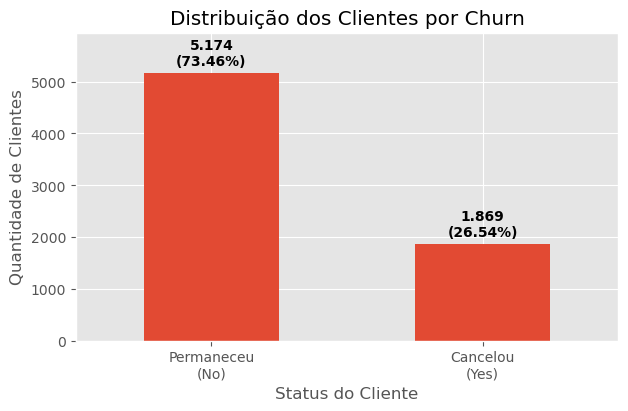

In [17]:
# ============================================================
# ETAPA 13 - VISUALIZAÇÃO DA DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ============================================================
# Construindo um gráfico de barras para visualizar a quantidade
# de clientes que permaneceram e dos que cancelaram o serviço.
# ============================================================


plt.figure(figsize=(7,4))
ax = churn_count.plot(kind="bar")

# Altera os rótulos do eixo X
ax.set_xticklabels([
    "Permaneceu\n(No)",
    "Cancelou\n(Yes)"
])

plt.title("Distribuição dos Clientes por Churn")
plt.xlabel("Status do Cliente")
plt.ylabel("Quantidade de Clientes")

plt.xticks(rotation=0)

plt.ylim(0, churn_count.max() * 1.15)

# Adiciona os percentuais sobre as barras
for i, valor in enumerate(churn_count):
    percentual = churn_percent.iloc[i] * 100

    ax.text(
        i,
        valor + 80,
        f"{valor:,}\n({percentual:.2f}%)".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.show()

#### Conclusão da visualização da variável alvo

A representação gráfica confirma a predominância da classe `No`, sem caracterizar um desbalanceamento extremo.

A diferença entre as classes reforça a necessidade de utilizar divisão estratificada dos dados e métricas de avaliação adequadas à identificação da classe positiva (`Churn = Yes`).

---

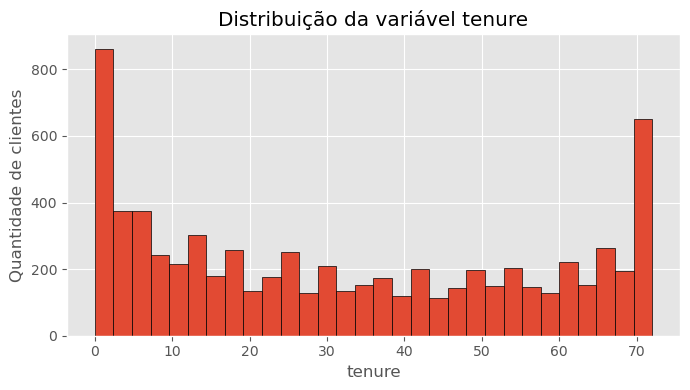

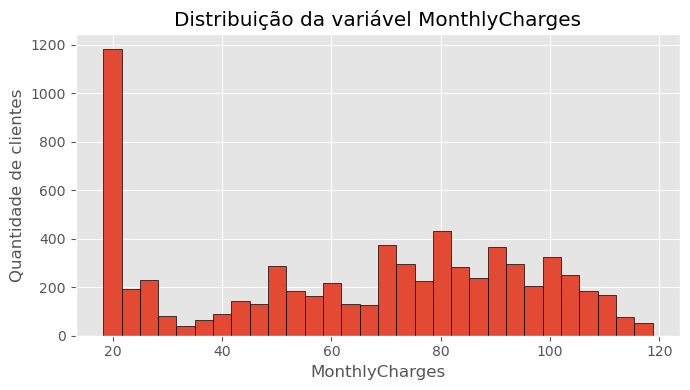

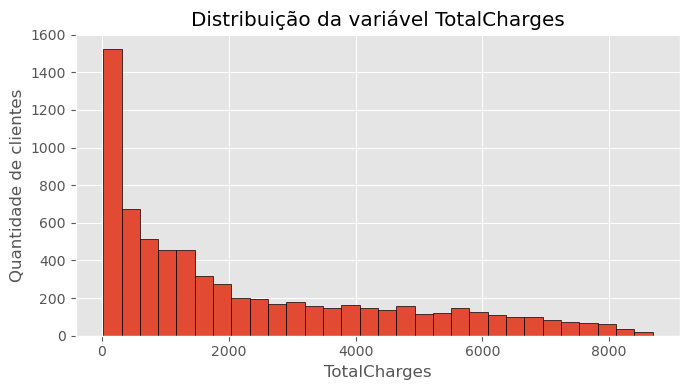

In [18]:
# ============================================================
# ETAPA 14 - DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS
# ============================================================
# Construindo histogramas para analisar a distribuição das
# variáveis tenure, MonthlyCharges e TotalCharges.
# ============================================================

numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribuição da variável {column}")
    plt.xlabel(column)
    plt.ylabel("Quantidade de clientes")

    plt.tight_layout()
    plt.show()

#### Conclusão das distribuições numéricas

A análise das variáveis numéricas (**tenure**, **MonthlyCharges** e **TotalCharges**) permitiu compreender melhor o perfil dos clientes presentes na base de dados.

A variável **tenure** apresentou maior concentração de clientes nos extremos da distribuição, indicando a presença tanto de clientes recém-adquiridos quanto de clientes com longo tempo de permanência na empresa. Já a variável **MonthlyCharges** mostrou uma distribuição heterogênea, refletindo diferentes perfis de planos e serviços contratados pelos clientes. Por sua vez, **TotalCharges** apresentou uma distribuição assimétrica à direita, com maior concentração de clientes em valores acumulados mais baixos e redução gradual da frequência à medida que o valor total aumenta.

Esses resultados são coerentes com o contexto do negócio, uma vez que clientes com menor tempo de permanência tendem a acumular menores valores de cobrança, enquanto clientes mais antigos apresentam maiores valores pagos ao longo do relacionamento com a empresa.

Nas próximas etapas da Análise Exploratória de Dados (EDA), essas variáveis serão relacionadas à variável alvo (**Churn**) para investigar se o tempo de permanência, o valor da mensalidade e o valor total acumulado possuem influência no cancelamento dos serviços.

---

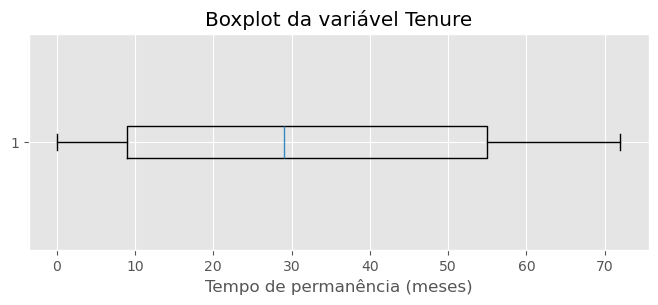

In [20]:
# ============================================================
# ETAPA 15.1 - BOXPLOT DA VARIÁVEL TENURE
# ============================================================
# Construindo um boxplot para identificar possíveis valores
# extremos na variável de tempo de permanência dos clientes.
# ============================================================

plt.figure(figsize=(8, 2.8))

plt.boxplot(df["tenure"], vert=False)

plt.title("Boxplot da variável Tenure")
plt.xlabel("Tempo de permanência (meses)")

plt.show()

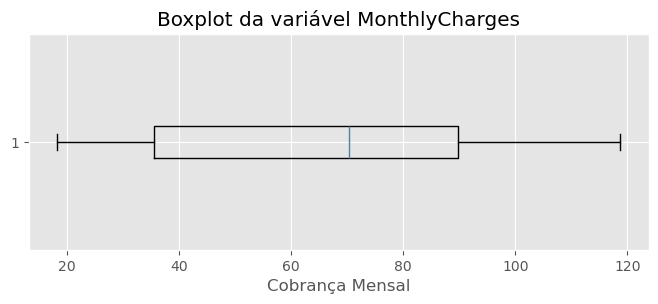

In [21]:
# ============================================================
# ETAPA 15.2 - BOXPLOT DA VARIÁVEL MONTHLYCHARGES
# ============================================================
# Construindo um boxplot para identificar possíveis valores
# extremos na variável de cobrança mensal.
# ============================================================

plt.figure(figsize=(8, 2.8))

plt.boxplot(df["MonthlyCharges"], vert=False)

plt.title("Boxplot da variável MonthlyCharges")
plt.xlabel("Cobrança Mensal")

plt.show()

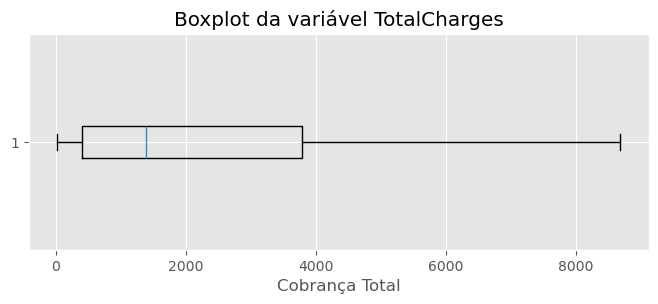

In [22]:
# ============================================================
# ETAPA 15.3 - BOXPLOT DA VARIÁVEL TOTALCHARGES
# ============================================================
# Construindo um boxplot para identificar possíveis valores
# extremos na variável de cobrança total acumulada.
# ============================================================

plt.figure(figsize=(8, 2.8))

plt.boxplot(df["TotalCharges"].dropna(), vert=False)

plt.title("Boxplot da variável TotalCharges")
plt.xlabel("Cobrança Total")

plt.show()

#### Conclusão dos boxplots

A inspeção dos boxplots não identificou valores extremos que, apenas com base na análise exploratória, justifiquem remoção automática de registros.

Os valores observados permanecem dentro de faixas plausíveis para o contexto das variáveis analisadas.

Dessa forma, não será realizada remoção de registros baseada exclusivamente em critérios de outliers nesta etapa.

---

Percentual de Churn por Tipo de Contrato:


,Permaneceu,Cancelou
Mensal,57.29,42.71
Anual,88.73,11.27
Dois anos,97.17,2.83


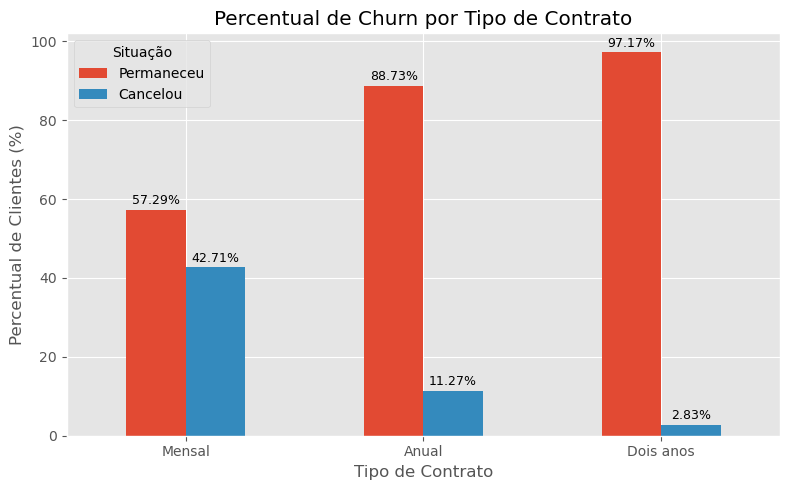

In [23]:
# ============================================================
# ETAPA 16.1 - CONTRATO X CHURN
# ============================================================
# Analisando a distribuição do cancelamento dos clientes de
# acordo com o tipo de contrato, utilizando valores percentuais
# e um gráfico de barras para facilitar a comparação entre as
# categorias.
# ============================================================

# Calculando o percentual de churn por tipo de contrato
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

# Traduzindo os tipos de contrato
contract_churn.index = [
    "Mensal",
    "Anual",
    "Dois anos"
]

# Traduzindo as colunas
contract_churn.columns = [
    "Permaneceu",
    "Cancelou"
]

print("Percentual de Churn por Tipo de Contrato:")
display(contract_churn)

# ============================================================
# Gráfico
# ============================================================

ax = contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentual de Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Percentual de Clientes (%)")

plt.xticks(rotation=0)

plt.legend(title="Situação")

# Adicionando os percentuais nas barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Conclusão da análise de Contract

A análise do tipo de contrato evidencia uma forte relação entre essa variável e o cancelamento dos clientes.

Observa-se que clientes com contrato **Mensal** apresentam a maior taxa de churn, com aproximadamente **42,71%** de cancelamentos. Em contrapartida, clientes com contratos **Anual** e de **Dois anos** apresentam taxas significativamente menores, de **11,27%** e **2,83%**, respectivamente.

Esse resultado sugere que contratos com maior período de fidelização estão associados a uma menor probabilidade de cancelamento, tornando a variável **Contract** um importante preditor para os modelos de Machine Learning.

---

Distribuição percentual do Churn por tipo de serviço de internet:


,Permaneceu,Cancelou
DSL,81.04,18.96
Fibra Óptica,58.11,41.89
Sem Internet,92.60,7.40


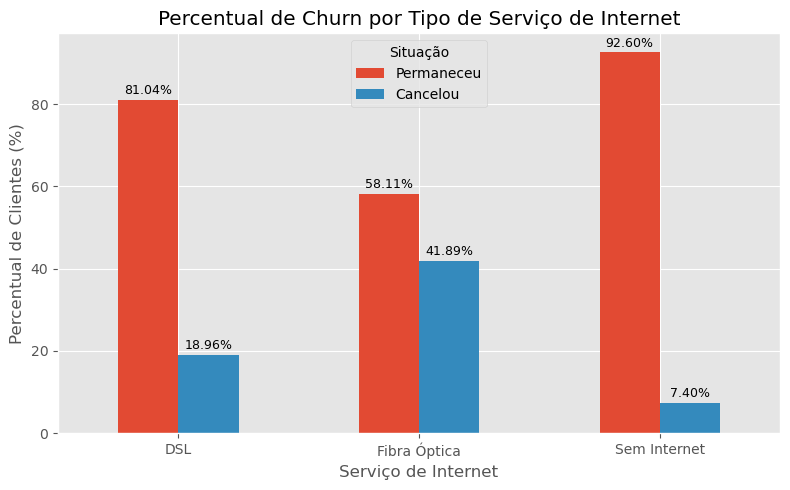

In [24]:
# ============================================================
# ETAPA 16.2 - SERVIÇO DE INTERNET X CHURN
# ============================================================
# Analisando a distribuição do cancelamento dos clientes de
# acordo com o tipo de serviço de internet contratado.
# ============================================================

# Calculando o percentual de churn por tipo de serviço
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

# Traduzindo os tipos de serviço
internet_churn.index = [
    "DSL",
    "Fibra Óptica",
    "Sem Internet"
]

# Traduzindo as colunas
internet_churn.columns = [
    "Permaneceu",
    "Cancelou"
]

print("Distribuição percentual do Churn por tipo de serviço de internet:")
display(internet_churn)

# ============================================================
# Gráfico
# ============================================================

ax = internet_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Percentual de Churn por Tipo de Serviço de Internet")
plt.xlabel("Serviço de Internet")
plt.ylabel("Percentual de Clientes (%)")

plt.xticks(rotation=0)

plt.legend(title="Situação")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Conclusão da análise de InternetService

A análise do tipo de serviço de internet evidencia uma relação significativa entre essa variável e o cancelamento dos clientes.

Observa-se que clientes que utilizam **Fibra Óptica** apresentam a maior taxa de churn, com aproximadamente **41,89%** de cancelamentos. Em contrapartida, clientes com serviço **DSL** apresentam uma taxa de **18,96%**, enquanto aqueles que **não possuem serviço de internet** registram o menor percentual de churn, com apenas **7,40%**.

Esses resultados indicam que o tipo de serviço contratado pode influenciar o comportamento dos clientes em relação ao cancelamento. Embora a análise exploratória não permita identificar a causa dessa diferença, fatores como qualidade do serviço, perfil dos clientes, preço dos planos ou expectativas em relação ao serviço podem contribuir para esse comportamento.

Dessa forma, a variável **InternetService** demonstra potencial para contribuir significativamente na previsão do churn e deverá ser considerada durante a construção dos modelos de Machine Learning.

---

Distribuição percentual do Churn por método de pagamento:


,Permaneceu,Cancelou
Transferência Bancária Automática,83.29,16.71
Cartão de Crédito Automático,84.76,15.24
Cheque Eletrônico,54.71,45.29
Cheque Enviado,80.89,19.11


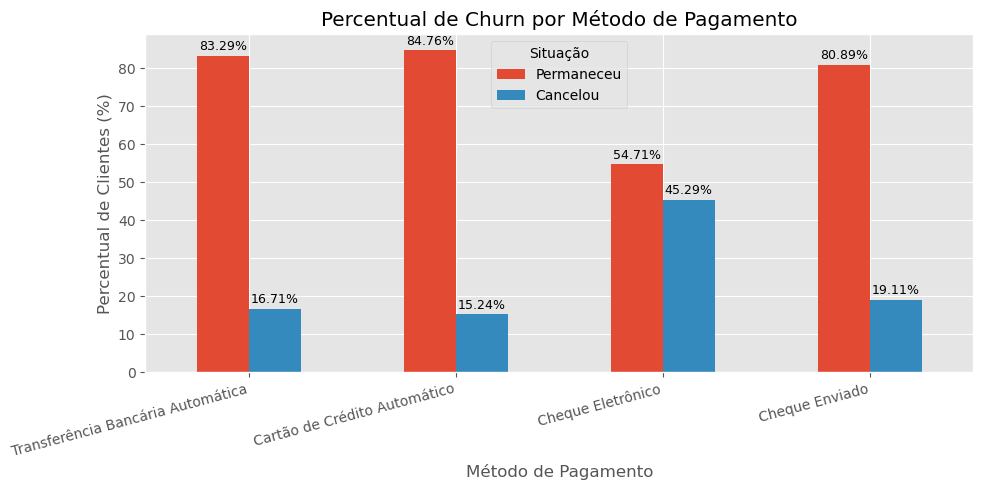

In [25]:
# ============================================================
# ETAPA 16.3 - MÉTODO DE PAGAMENTO X CHURN
# ============================================================
# Analisando a distribuição do cancelamento dos clientes de
# acordo com o método de pagamento utilizado.
# ============================================================

# Calculando o percentual de churn por método de pagamento
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

# Traduzindo os métodos de pagamento
payment_churn.index = [
    "Transferência Bancária Automática",
    "Cartão de Crédito Automático",
    "Cheque Eletrônico",
    "Cheque Enviado"
]

# Traduzindo as colunas
payment_churn.columns = [
    "Permaneceu",
    "Cancelou"
]

print("Distribuição percentual do Churn por método de pagamento:")
display(payment_churn)

# ============================================================
# Gráfico
# ============================================================

ax = payment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Percentual de Churn por Método de Pagamento")
plt.xlabel("Método de Pagamento")
plt.ylabel("Percentual de Clientes (%)")

plt.xticks(rotation=15, ha="right")

plt.legend(title="Situação")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Conclusão da análise de PaymentMethod

A análise do método de pagamento demonstra que essa variável apresenta uma associação relevante com o cancelamento dos clientes.

Observa-se que clientes que utilizam **Cheque Eletrônico** apresentam a maior taxa de churn, com aproximadamente **45,29%** de cancelamentos, percentual significativamente superior aos demais métodos de pagamento.

Em contrapartida, clientes que utilizam **Cartão de Crédito Automático** e **Transferência Bancária Automática** apresentam as menores taxas de churn, com **15,24%** e **16,71%**, respectivamente. O método **Cheque Enviado** também apresentou uma taxa relativamente baixa de cancelamento (**19,11%**).

Esses resultados sugerem que clientes que utilizam métodos de pagamento automáticos tendem a permanecer por mais tempo na empresa, enquanto aqueles que realizam pagamentos por **Cheque Eletrônico** apresentam maior propensão ao cancelamento. Embora a Análise Exploratória de Dados não permita estabelecer uma relação de causa e efeito, essa variável demonstra potencial para contribuir significativamente na previsão do churn e deverá ser considerada durante a construção dos modelos de Machine Learning.

---

Distribuição percentual do Churn por serviço de Segurança Online:


,Permaneceu,Cancelou
Não,58.23,41.77
Sem Internet,92.60,7.40
Sim,85.39,14.61


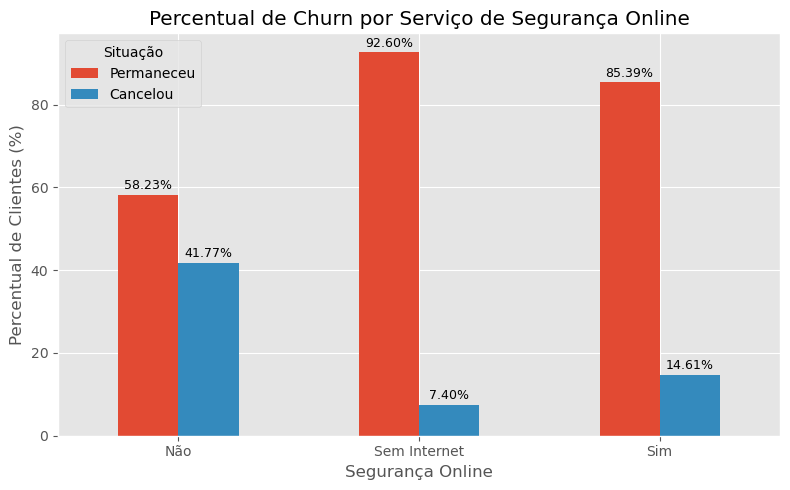

In [26]:
# ============================================================
# ETAPA 16.4 - SEGURANÇA ONLINE X CHURN
# ============================================================
# Analisando a distribuição do cancelamento dos clientes de
# acordo com a contratação do serviço de Segurança Online.
# ============================================================

# Calculando o percentual de churn por serviço de segurança online
security_churn = (
    pd.crosstab(
        df["OnlineSecurity"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

# Traduzindo as categorias
security_churn.index = [
    "Não",
    "Sem Internet",
    "Sim"
]

# Traduzindo as colunas
security_churn.columns = [
    "Permaneceu",
    "Cancelou"
]

print("Distribuição percentual do Churn por serviço de Segurança Online:")
display(security_churn)

# ============================================================
# Gráfico
# ============================================================

ax = security_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Percentual de Churn por Serviço de Segurança Online")
plt.xlabel("Segurança Online")
plt.ylabel("Percentual de Clientes (%)")

plt.xticks(rotation=0)

plt.legend(title="Situação")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Conclusão da análise de OnlineSecurity

A análise da variável **OnlineSecurity** evidencia uma forte associação entre a contratação do serviço de Segurança Online e o cancelamento dos clientes.

Observa-se que clientes que **não possuem Segurança Online** apresentam uma taxa de churn de aproximadamente **41,77%**, quase três vezes superior à observada entre clientes que contrataram esse serviço (**14,61%**). Já os clientes que **não possuem serviço de internet** registram a menor taxa de cancelamento, com **7,40%**.

Esses resultados sugerem que clientes que contratam o serviço de Segurança Online tendem a permanecer por mais tempo na empresa, enquanto aqueles que não utilizam esse recurso apresentam maior propensão ao cancelamento. Embora a Análise Exploratória de Dados não permita estabelecer uma relação de causa e efeito, a variável **OnlineSecurity** demonstra elevado potencial para contribuir na previsão do churn e deverá ser considerada durante a construção dos modelos de Machine Learning.

---

Distribuição percentual do Churn por serviço de Suporte Técnico:


,Permaneceu,Cancelou
Não,58.36,41.64
Sem Internet,92.60,7.40
Sim,84.83,15.17


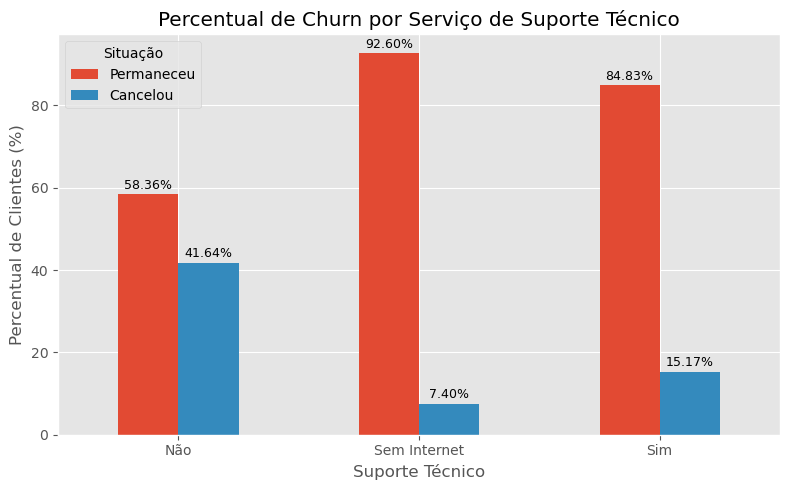

In [27]:
# ============================================================
# ETAPA 16.5 - SUPORTE TÉCNICO X CHURN
# ============================================================
# Analisando a distribuição do cancelamento dos clientes de
# acordo com a contratação do serviço de Suporte Técnico.
# ============================================================

# Calculando o percentual de churn por serviço de suporte técnico
support_churn = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

# Traduzindo as categorias
support_churn.index = [
    "Não",
    "Sem Internet",
    "Sim"
]

# Traduzindo as colunas
support_churn.columns = [
    "Permaneceu",
    "Cancelou"
]

print("Distribuição percentual do Churn por serviço de Suporte Técnico:")
display(support_churn)

# ============================================================
# Gráfico
# ============================================================

ax = support_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentual de Churn por Serviço de Suporte Técnico")
plt.xlabel("Suporte Técnico")
plt.ylabel("Percentual de Clientes (%)")

plt.xticks(rotation=0)

plt.legend(title="Situação")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Conclusão da análise de TechSupport

A análise da variável **TechSupport** evidencia uma forte associação entre a contratação do serviço de Suporte Técnico e o cancelamento dos clientes.

Observa-se que clientes que **não possuem Suporte Técnico** apresentam uma taxa de churn de aproximadamente **41,64%**, percentual significativamente superior ao observado entre clientes que contrataram esse serviço (**15,17%**). Os clientes que **não possuem serviço de internet** apresentam a menor taxa de cancelamento, com **7,40%**.

Esses resultados sugerem que clientes que utilizam o serviço de Suporte Técnico tendem a permanecer por mais tempo na empresa, enquanto aqueles que não contratam esse serviço apresentam maior propensão ao cancelamento. Embora a Análise Exploratória de Dados não permita estabelecer uma relação de causa e efeito, a variável **TechSupport** demonstra elevado potencial para contribuir na previsão do churn e deverá ser considerada durante a construção dos modelos de Machine Learning.

---

Estatísticas do tempo de permanência por situação do cliente:


,count,mean,std,min,25%,50%,75%,max
Permaneceu,"5,174.00",37.57,24.11,0.00,15.00,38.00,61.00,72.00
Cancelou,"1,869.00",17.98,19.53,1.00,2.00,10.00,29.00,72.00


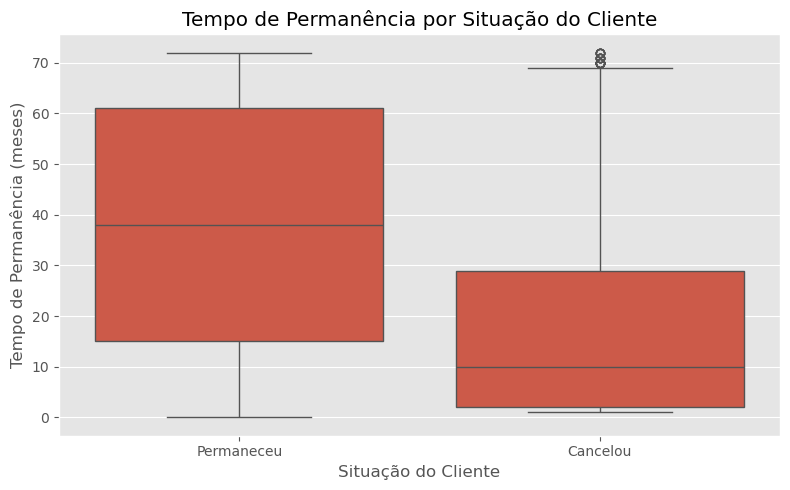

In [28]:
# ============================================================
# ETAPA 16.6 - TEMPO DE PERMANÊNCIA (TENURE) X CHURN
# ============================================================
# Comparando a distribuição do tempo de permanência dos clientes
# que permaneceram e dos que cancelaram o serviço.
# ============================================================

# Estatísticas descritivas
tenure_churn = (
    df.groupby("Churn")["tenure"]
      .describe()
      .round(2)
)

# Traduzindo os índices
tenure_churn.index = [
    "Permaneceu",
    "Cancelou"
]

print("Estatísticas do tempo de permanência por situação do cliente:")
display(tenure_churn)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tempo de Permanência por Situação do Cliente")
plt.xlabel("Situação do Cliente")
plt.ylabel("Tempo de Permanência (meses)")

plt.xticks(
    [0, 1],
    ["Permaneceu", "Cancelou"]
)

plt.tight_layout()
plt.show()

#### Conclusão da análise de Tenure

A análise da variável **tenure** evidencia uma forte associação entre o tempo de permanência do cliente e o cancelamento do serviço.

Observa-se que clientes que permaneceram na empresa apresentam um tempo de permanência significativamente superior ao dos clientes que cancelaram. Enquanto os clientes ativos possuem média de **37,57 meses** e mediana de **38 meses**, os clientes que cancelaram apresentam média de apenas **17,98 meses** e mediana de **10 meses**.

O boxplot reforça essa diferença ao demonstrar que a maior parte dos clientes que cancelaram possui baixo tempo de permanência, concentrando-se nos primeiros meses de contrato. Embora existam alguns clientes antigos que também cancelaram o serviço, esses representam uma parcela reduzida da base de dados.

Esses resultados indicam que clientes recém-adquiridos apresentam maior propensão ao cancelamento, enquanto clientes com maior tempo de relacionamento tendem a permanecer na empresa. Dessa forma, a variável **tenure** demonstra elevado potencial preditivo e deverá exercer papel importante na construção dos modelos de Machine Learning.

---

Estatísticas da cobrança mensal por situação do cliente:


,count,mean,std,min,25%,50%,75%,max
Permaneceu,"5,174.00",61.27,31.09,18.25,25.10,64.43,88.40,118.75
Cancelou,"1,869.00",74.44,24.67,18.85,56.15,79.65,94.20,118.35


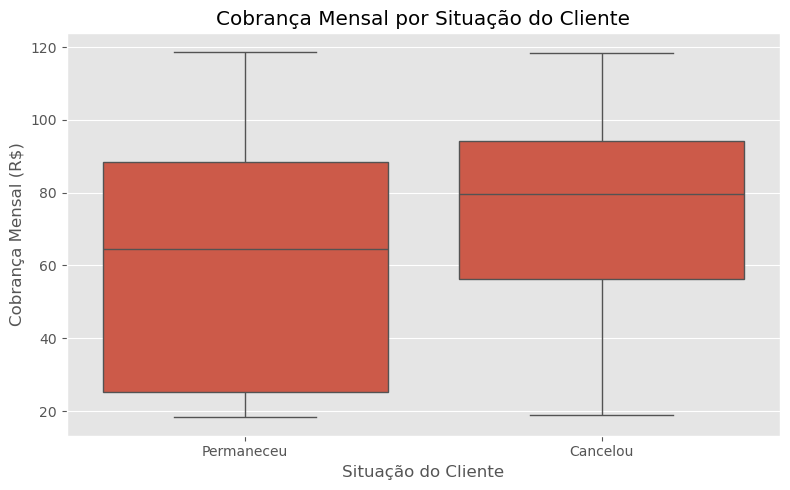

In [29]:
# ============================================================
# ETAPA 16.7 - COBRANÇA MENSAL (MONTHLYCHARGES) X CHURN
# ============================================================
# Comparando a distribuição da cobrança mensal entre os clientes
# que permaneceram e os que cancelaram o serviço.
# ============================================================

# Estatísticas descritivas
monthly_churn = (
    df.groupby("Churn")["MonthlyCharges"]
      .describe()
      .round(2)
)

# Traduzindo os índices
monthly_churn.index = [
    "Permaneceu",
    "Cancelou"
]

print("Estatísticas da cobrança mensal por situação do cliente:")
display(monthly_churn)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Cobrança Mensal por Situação do Cliente")
plt.xlabel("Situação do Cliente")
plt.ylabel("Cobrança Mensal (R$)")

plt.xticks(
    [0, 1],
    ["Permaneceu", "Cancelou"]
)

plt.tight_layout()
plt.show()

#### Conclusão da análise de MonthlyCharges

A análise da variável **MonthlyCharges** evidencia uma associação entre o valor da cobrança mensal e o cancelamento dos clientes.

Observa-se que clientes que cancelaram o serviço apresentam mensalidades mais elevadas em comparação aos clientes que permaneceram. Enquanto os clientes ativos possuem cobrança mensal média de **R$ 61,27** e mediana de **R$ 64,43**, os clientes que cancelaram apresentam média de **R$ 74,44** e mediana de **R$ 79,65**.

O boxplot confirma essa diferença ao demonstrar que a distribuição das cobranças mensais dos clientes que cancelaram está concentrada em valores superiores aos observados entre os clientes que permaneceram. Apesar de existir sobreposição entre os grupos, nota-se uma tendência consistente de maior cancelamento entre clientes com mensalidades mais altas.

Esses resultados sugerem que o valor da mensalidade pode influenciar a decisão de cancelamento, possivelmente devido à percepção de custo-benefício ou à busca por alternativas mais econômicas. Embora a Análise Exploratória de Dados não permita estabelecer uma relação de causa e efeito, a variável **MonthlyCharges** demonstra elevado potencial preditivo e deverá ser considerada na construção dos modelos de Machine Learning.

---

Matriz de Correlação:


Variável,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Variável,,,,
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


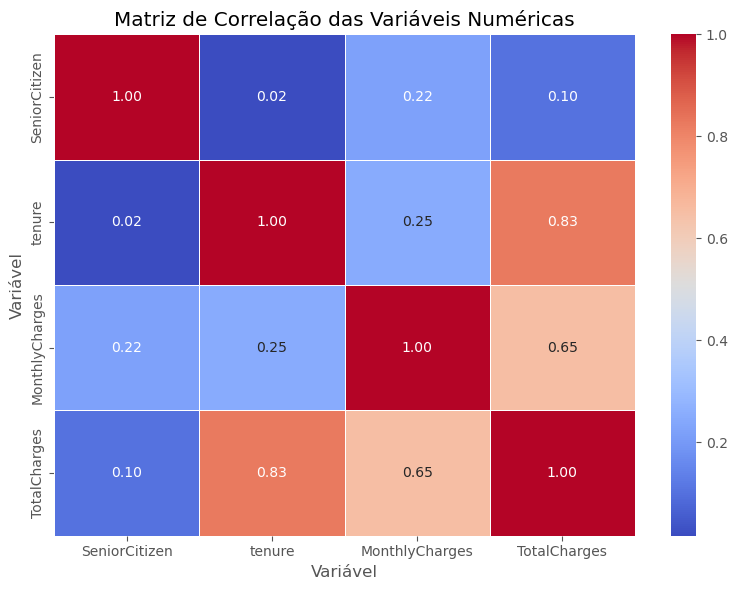

In [30]:
# ============================================================
# ETAPA 17 - MATRIZ DE CORRELAÇÃO
# ============================================================
# Avaliando a correlação linear entre as variáveis numéricas
# do conjunto de dados.
# ============================================================

# Selecionando apenas as variáveis numéricas
corr = df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].corr()

print("Matriz de Correlação:")
display(corr)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas")

plt.tight_layout()
plt.show()

#### Conclusão da matriz de correlação

A maior associação linear ocorre entre `tenure` e `TotalCharges`, resultado esperado, uma vez que clientes com maior tempo de permanência tendem a acumular maior valor total de cobranças.

Também se observa associação moderada entre `MonthlyCharges` e `TotalCharges`, enquanto as demais correlações lineares apresentam menor intensidade.

A correlação elevada entre `tenure` e `TotalCharges` deverá ser considerada durante a modelagem, especialmente em modelos lineares. Caso necessário, análises adicionais poderão ser utilizadas para avaliar possíveis efeitos de multicolinearidade.

> **Nota:** `SeniorCitizen` é armazenada numericamente como 0/1, mas representa conceitualmente uma variável binária categórica. Sua inclusão nesta matriz possui finalidade exploratória e não implica seu tratamento como variável numérica contínua durante a modelagem.

---

### Avaliação de Data Readiness

A Análise Exploratória dos Dados indica que o dataset apresenta condições adequadas para avançar para a etapa de modelagem, desde que os tratamentos identificados sejam incorporados de forma consistente ao pipeline de Machine Learning.

#### Qualidade observada

- 7.043 registros disponíveis;
- 21 variáveis no dataset original;
- ausência de registros duplicados;
- `customerID` único por cliente;
- 11 valores ausentes em `TotalCharges` após conversão para formato numérico;
- baixa cardinalidade nas principais variáveis categóricas;
- ausência de valores extremos que justifiquem remoção automática;
- desbalanceamento moderado da variável alvo, com aproximadamente 26,54% de churn.

#### Tratamentos necessários para modelagem

1. Excluir `customerID` das features preditoras.
2. Tratar os valores ausentes de `TotalCharges`.
3. Codificar as variáveis categóricas.
4. Aplicar escalonamento às variáveis numéricas quando necessário.
5. Converter `Churn` para representação binária:
   - `No = 0`;
   - `Yes = 1`.
6. Utilizar divisão estratificada dos dados.
7. Ajustar transformações exclusivamente sobre os dados de treino para evitar data leakage.
8. Encapsular o pré-processamento em pipelines reproduzíveis do Scikit-Learn.

#### Conclusão de Data Readiness

O dataset é considerado **adequado para prosseguir para a modelagem**, condicionado à aplicação consistente dos tratamentos descritos.

As transformações serão implementadas por meio de pipelines para garantir que o mesmo fluxo de preparação seja utilizado durante treinamento, avaliação e inferência.

---

### Decisões Derivadas da EDA para Modelagem

Os resultados da análise exploratória orientam as principais decisões técnicas das próximas etapas do projeto.

| Evidência observada | Decisão para modelagem |
|---|---|
| `customerID` é único por cliente | Excluir da matriz de features |
| `TotalCharges` possui 11 valores ausentes após conversão | Implementar tratamento no pipeline de pré-processamento |
| Variáveis categóricas apresentam baixa cardinalidade | Aplicar codificação categórica, como One-Hot Encoding |
| Variáveis numéricas possuem escalas distintas | Aplicar escalonamento quando necessário ao algoritmo |
| Churn representa aproximadamente 26,54% da base | Utilizar divisão estratificada entre treino e teste |
| A classe positiva é minoritária | Priorizar PR-AUC e reportar métricas complementares |
| Foram observados possíveis padrões não lineares | Avaliar modelos baseados em árvores/ensemble |
| É necessário estabelecer uma referência inicial | Utilizar Regressão Logística como baseline |
| Falsos positivos e falsos negativos possuem impactos distintos | Avaliar matriz de confusão e métricas de negócio |
| Transformações realizadas antes da separação dos dados podem gerar leakage | Ajustar o pré-processamento exclusivamente sobre os dados de treino |
| É necessária uma referência mínima independente de aprendizado | Utilizar `DummyClassifier` como baseline ingênuo |


---

## Conclusão da Análise Exploratória

A Análise Exploratória dos Dados permitiu compreender a estrutura, a qualidade e os principais padrões presentes no dataset Telco Customer Churn.

O conjunto apresenta boa qualidade geral e condições adequadas para avançar à modelagem. As principais necessidades de preparação estão relacionadas ao tratamento de `TotalCharges`, à exclusão de `customerID`, à codificação das variáveis categóricas e à aplicação consistente das transformações por meio de pipelines.

A análise também identificou associações relevantes entre churn e características como tempo de permanência, tipo de contrato, serviço de internet, método de pagamento, serviços adicionais e cobrança mensal. Essas associações possuem caráter exploratório e sua contribuição preditiva será validada durante o treinamento e a comparação dos modelos.

Com base nas evidências obtidas, a próxima etapa formalizará as métricas técnicas e de negócio utilizadas na avaliação. Em seguida, serão estabelecidas as referências com `DummyClassifier` e Regressão Logística e treinados os modelos candidatos para comparação e seleção do modelo campeão.

A preparação e a modelagem serão conduzidas por meio de pipelines reproduzíveis, com separação adequada entre treino e teste, visando reduzir riscos de *data leakage* e garantir consistência entre treinamento, avaliação e inferência.

---